# Semana 12 - Practicar Matplotlib

**Propósito:** aplicar `pandas` y `matplotlib` para explorar, graficar e interpretar datos reales de nacimientos y defunciones.

Este notebook está dividido en tres niveles:

- **Nivel básico:** cargar, revisar y limpiar datos.
- **Nivel intermedio:** crear gráficos correctos y explicar lo observado.
- **Reto final:** diseñar un gráfico propio para responder una pregunta.


## Criterios de logro

Al completar la práctica, su entrega debe demostrar que puede:

- Cargar un CSV y revisar su estructura.
- Seleccionar, filtrar y crear columnas nuevas.
- Crear gráficos con título, etiquetas, leyenda y tamaño adecuado.
- Interpretar los gráficos con frases claras.
- Justificar qué tipo de gráfico eligió.


## Nivel básico - 1. Preparación

Ejecute esta celda para cargar las bibliotecas y el archivo de datos.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

df = pd.read_csv("nacimientos_defunciones.csv")
print(" valores nulos por columna:")
print(df.isnull().sum())
df.head()

filtro_nulos = df.isna().any(axis=1)
df[~filtro_nulos]


#calcular todos los nulos 

#import pandas as pd
#import matplotlib.pyplot as plt
#plt.style.use("seaborn-v0_8-whitegrid")
#df = pd.read_csv("nacimientos_defunciones.csv", na_values="NULL", encoding="utf-8", encoding_errors="ignore")
# Convertir la columna 'Nacimientos' a numérica, forzando los errores a NaN
#df["Nacimientos"] = df['Nacimientos'].apply(pd.to_numeric, errors='coerce')
#print(df.head()) 
#print(df.info()) 
#print("\nValores nulos por columna:")
#print(df.isna().sum()) 
#filtro_nulos = df.isna().any(axis=1)
#df[filtro_nulos]

 valores nulos por columna:
Año            0
Nacimientos    2
Defunciones    1
dtype: int64


,Año,Nacimientos,Defunciones
0,1950,37248.0,9769.0
1,1951,39239.0,9631.0
2,1952,42461.0,9902.0
3,1953,42817.0,10312.0
4,1954,48157.0,9713.0
...,...,...,...
67,2017,68811.0,23246.0
68,2018,68449.0,23806.0
69,2019,64274.0,24292.0
70,2020,57848.0,26205.0


## Nivel básico - 2. Exploración inicial

Complete las instrucciones. La meta es conocer el DataFrame antes de graficar.


In [16]:
# TODO: muestre la cantidad de filas y columnas con df.shape
df.shape
# TODO: muestre los nombres de las columnas con df.columns
df.columns
# TODO: muestre los tipos de datos con df.dtypes
df.dtypes
# TODO: muestre un resumen estadístico con df.describe()
df.describe()

,Año,Nacimientos,Defunciones
count,72.00000,70.000000,71.000000
mean,1985.50000,67547.928571,13613.521127
std,20.92845,11371.397923,4875.340697
min,1950.00000,37248.000000,8596.000000
25%,1967.75000,59401.000000,9950.000000
50%,1985.50000,70277.000000,11379.000000
75%,2003.25000,76097.500000,15874.500000
max,2021.00000,84337.000000,31093.000000


**Pregunta de interpretación:** ¿qué años cubre el archivo y cuántos registros tiene?


## Nivel básico - 3. Limpieza básica

Antes de analizar, confirme si hay valores nulos.


In [17]:
# TODO: muestre cuántos valores nulos hay por columna
df.isnull().sum()
# TODO: elimine filas con valores nulos, si existieran
df.dropna(inplace=True)
# TODO: vuelva a revisar los valores nulos
df.isnull().sum()


Año            0
Nacimientos    0
Defunciones    0
dtype: int64

**Pista:** puede usar `df.isna().sum()` y `df.dropna(inplace=True)`.


## Nivel básico - 4. Selección de columnas

Cree un DataFrame solo con `Año` y `Nacimientos`.


In [18]:
# TODO: cree un DataFrame llamado df_nacimientos con las columnas Año y Nacimientos
# df_nacimientos = ...
df_nacimientos = df[["Año", "Nacimientos"]]
# TODO: muestre las primeras 5 filas
df_nacimientos.head() 

,Año,Nacimientos
0,1950,37248.0
1,1951,39239.0
2,1952,42461.0
3,1953,42817.0
4,1954,48157.0


**Pregunta de interpretación:** ¿por qué conviene crear DataFrames más pequeños para ciertos análisis?


## Nivel básico - 5. Filtrado de datos

Cree un DataFrame con datos desde 2010 en adelante.


In [19]:
# TODO: cree un DataFrame llamado df_2010 con datos desde el año 2010
# df_2010 = ...
df_2010 = df[df["Año"] >= 2010]
# TODO: muestre los datos filtrados
df_2010 = df[df["Año"] >= 2010]
df_2010.head()

,Año,Nacimientos,Defunciones
60,2010,70922.0,19077.0
61,2011,73459.0,18801.0
62,2012,73326.0,19200.0
63,2013,70550.0,19646.0
64,2014,71793.0,20560.0


**Pista:** use una condición como `df["Año"] >= 2010`.


## Nivel intermedio - 6. Cálculos básicos

Calcule totales y agregue una columna nueva.


In [27]:
# TODO: calcule el total de nacimientos
# total_nacimientos = ...
total_nacimientos = df["Nacimientos"].sum()

# TODO: calcule el total de defunciones
# total_defunciones = ...
total_defunciones = df["Defunciones"].sum()
# TODO: cree la columna Saldo Poblacional
# df["Saldo Poblacional"] = ...
df["Saldo Poblacional"] = df["Nacimientos"] - df["Defunciones"]
# TODO: muestre total_nacimientos, total_defunciones y df.head()
print(f"Total de Nacimientos: {total_nacimientos}")
print(f"Total de Defunciones: {total_defunciones}")
print(f"Saldo poblacional calculado en el DataFrame: {df['Saldo Poblacional'].sum():,}")
df.head()

Total de Nacimientos: 4656100.0
Total de Defunciones: 945529.0
Saldo poblacional calculado en el DataFrame: 3,710,571.0


,Año,Nacimientos,Defunciones,Saldo Poblacional
0,1950,37248.0,9769.0,27479.0
1,1951,39239.0,9631.0,29608.0
2,1952,42461.0,9902.0,32559.0
3,1953,42817.0,10312.0,32505.0
4,1954,48157.0,9713.0,38444.0


**Pregunta de interpretación:** ¿qué significa el saldo poblacional en este conjunto de datos?


## Nivel intermedio - 7. Gráfico de líneas: nacimientos por año

Cree un gráfico de líneas con `Año` en el eje X y `Nacimientos` en el eje Y.


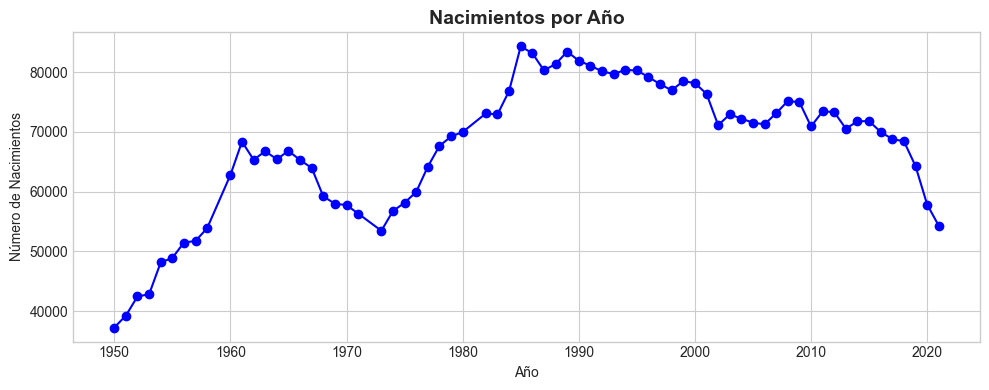

In [39]:
# TODO: cree una figura con figsize=(10, 4)
# TODO: grafique Año vs Nacimientos
# TODO: agregue título, etiqueta X, etiqueta Y y plt.tight_layout()
# TODO: muestre el gráfico con plt.show()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df["Año"], df["Nacimientos"], marker="o", linestyle="-", color="blue")
ax.set_title("Nacimientos por Año", fontsize=14, fontweight="bold")
ax.set_xlabel("Año")
ax.set_ylabel("Número de Nacimientos")
plt.tight_layout()
plt.show()

**Pregunta de interpretación:** ¿los nacimientos muestran una tendencia general de aumento, disminución o estabilidad?


## Nivel intermedio - 8. Comparación de nacimientos y defunciones

Cree un gráfico con dos líneas y una leyenda.


In [ ]:
# TODO: cree fig, ax = plt.subplots(figsize=(10, 4))
# TODO: grafique Nacimientos y Defunciones contra Año
# TODO: use colores distintos y label en cada línea
# TODO: agregue título, etiquetas y leyenda
# TODO: aplique plt.tight_layout() y plt.show()


**Pregunta de interpretación:** ¿en qué parte del periodo la distancia entre nacimientos y defunciones parece mayor?


## Nivel intermedio - 9. Gráfico de barras del último año

Compare nacimientos y defunciones en el último año disponible.


In [ ]:
# TODO: obtenga el último año disponible con df["Año"].max()
# ultimo_anio = ...

# TODO: filtre la fila del último año
# datos_ultimo_anio = ...

# TODO: cree listas para categorias y valores
# categorias = ["Nacimientos", "Defunciones"]
# valores = ...

# TODO: cree un gráfico de barras con título y etiquetas


**Pregunta de interpretación:** ¿qué diferencia observa entre nacimientos y defunciones en el último año?


## Nivel intermedio - 10. Saldo poblacional desde 2010

Use los datos filtrados desde 2010 y grafique el saldo poblacional.


In [ ]:
# TODO: asegúrese de que df_2010 tenga una copia de los datos filtrados
# df_2010 = df[df["Año"] >= 2010].copy()

# TODO: cree la columna Saldo Poblacional en df_2010

# TODO: grafique Año vs Saldo Poblacional


**Pregunta de interpretación:** ¿el saldo poblacional desde 2010 sube, baja o se mantiene? Explique con base en el gráfico.


## Nivel intermedio - 11. Subgráficos

Cree una figura con dos subgráficos:

1. Nacimientos y defunciones por año.
2. Saldo poblacional por año.


In [ ]:
# TODO: cree fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# TODO: en axes[0], grafique nacimientos y defunciones por año

# TODO: en axes[1], grafique saldo poblacional por año

# TODO: agregue títulos, etiquetas y leyendas cuando corresponda

# TODO: use plt.tight_layout() y plt.show()


**Pregunta de interpretación:** ¿qué ventaja tiene ver ambos gráficos en una misma figura?


## Buenas prácticas antes del reto final

Revise que sus gráficos cumplan con estas reglas:

- El título explica el contenido del gráfico.
- Los ejes tienen nombres claros.
- La leyenda aparece cuando hay más de una serie.
- Los colores tienen un propósito.
- El gráfico responde una pregunta concreta.


## Reto final - 12. Pregunta propia

Construya un gráfico propio que responda una pregunta sobre los datos.

Ejemplos:

- ¿Cuáles son los 10 años con más nacimientos?
- ¿Cómo cambió el saldo poblacional en las últimas dos décadas?
- ¿Las defunciones aumentan o disminuyen con el tiempo?
- ¿Qué diferencia hay entre el primer y el último año del registro?


**Pregunta elegida:** escriba aquí la pregunta que desea responder.


In [ ]:
# TODO: cree el gráfico final
# Requisitos: título, etiquetas, tamaño adecuado e interpretación escrita debajo


**Interpretación final:** escriba 3 o 4 frases explicando qué muestra su gráfico y qué conclusión obtiene.


## Rúbrica breve

Use esta rúbrica para revisar su entrega:

| Criterio | Logrado | Pendiente |
|---|---|---|
| El notebook ejecuta sin errores |  |  |
| El CSV se carga correctamente |  |  |
| Se crean columnas y filtros solicitados |  |  |
| Los gráficos tienen título y etiquetas |  |  |
| Las interpretaciones responden las preguntas |  |  |
| El reto final tiene una pregunta clara |  |  |


## Cierre metacognitivo

Responda:

1. ¿Qué gráfico le ayudó más a entender los datos?
2. ¿Qué decisión visual cambió más la lectura del gráfico?
3. ¿Qué parte de Matplotlib necesita seguir practicando?
